In [1]:
import pandas as pd

df = pd.read_csv('dirty data.csv')

In [2]:
df.head(10)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6
5,459003,Male,Yes,47,Yes,Doctor,0.0,High,5.0,Cat_4
6,459005,Male,Yes,61,Yes,Doctor,5.0,Low,3.0,Cat_6
7,459008,Female,Yes,47,Yes,Artist,1.0,Average,3.0,Cat_6
8,459013,Male,Yes,50,Yes,Artist,2.0,Average,4.0,Cat_6
9,459014,Male,No,19,No,Healthcare,0.0,Low,4.0,Cat_6


In [3]:
df.shape

(2627, 10)

In [4]:
#datatype issues

df.dtypes

ID                   int64
Gender                 str
Ever_Married           str
Age                  int64
Graduated              str
Profession             str
Work_Experience    float64
Spending_Score         str
Family_Size        float64
Var_1                  str
dtype: object

In [5]:
# duplicate rows 

df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2622    False
2623    False
2624    False
2625    False
2626    False
Length: 2627, dtype: bool

In [6]:
# Value range anomalies

df.describe()

,ID,Age,Work_Experience,Family_Size
count,2627.000000,2627.000000,2358.000000,2514.000000
mean,463433.918919,43.649791,2.552587,2.825378
std,2618.245698,16.967015,3.341094,1.551906
min,458989.000000,18.000000,0.000000,1.000000
25%,461162.500000,30.000000,0.000000,2.000000
50%,463379.000000,41.000000,1.000000,2.000000
75%,465696.000000,53.000000,4.000000,4.000000
max,467968.000000,89.000000,14.000000,9.000000


In [7]:
# count of nulls per column

df.isnull().sum()

ID                   0
Gender               0
Ever_Married        50
Age                  0
Graduated           24
Profession          38
Work_Experience    269
Spending_Score       0
Family_Size        113
Var_1               32
dtype: int64

# Missing data handling

### we use mean because Work experience is int type.

In [8]:
df['Work_Experience']=df["Work_Experience"].fillna(df["Work_Experience"].mean())

### We use mode because profession is a sring type.

In [9]:
df['Profession'].mode()[0]

'Artist'

In [10]:
df["Profession"] = df["Profession"].fillna(df["Profession"].mode()[0])

### We use mode because Ever married column is a boolean type(Yes/No).

In [11]:
df["Ever_Married"] = df["Ever_Married"].fillna(df["Ever_Married"].mode()[0])

### We use mode because Graduted column is boolean type(yes/no)

In [12]:
df["Graduated"] = df["Graduated"].fillna(df["Graduated"].mode()[0])

### We use mean because Family Size is int type.

In [13]:
df["Family_Size"] = df["Family_Size"].fillna(df["Family_Size"].mean())

### We use mode because Var_1 is string type.

In [14]:
df["Var_1"] = df["Var_1"].fillna(df["Var_1"].mode()[0])

In [15]:
df.isnull().sum()

ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
dtype: int64

# Duplicate Remover

In [16]:
df.duplicated().sum()

np.int64(0)

### this data set has no duplicate so we use other data set


In [79]:
df1 = pd.read_csv('titanic_data.csv')


df1.duplicated().sum()

np.int64(107)

In [18]:
df1.head(30)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [19]:

print(df1[df1.duplicated()])


     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
47          1       3  female   NaN      0      0   7.7500        Q   Third   
76          0       3    male   NaN      0      0   7.8958        S   Third   
77          0       3    male   NaN      0      0   8.0500        S   Third   
87          0       3    male   NaN      0      0   8.0500        S   Third   
95          0       3    male   NaN      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
868         0       3    male  26.0      0      0   7.8958        S   Third   
875         0       3    male  19.0      0      0   7.8958        S   Third   
876         0       3    male   NaN      0      0   7.8958        S   Third   
882         0       3    male  25.0      0      0   7.0500        S   Third   
884         0       2    male  27.0      0      0  13.0000        S  Second   

       who  adult_male deck  embark_town alive  alo

In [20]:
df1 = df1.drop_duplicates()

In [21]:
print(df1[df1.duplicated()])

Empty DataFrame
Columns: [survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, alone]
Index: []


In [22]:
df1.duplicated().sum()

np.int64(0)

# Standardisation

## normalise inconsistent formatting 


In [24]:
df1["sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [26]:
df1["who"].unique()

<StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str

## there are no unique value so I try use another dataset


In [46]:
df2 = pd.read_csv('dirty_gender_date_dataset.csv')
df2.head()



,record_id,name,gender,customer,order_date
0,1,Alice,Male,Alice,2024-01-15
1,2,Bob,male,Bob,15/01/2024
2,3,Carol,MALE,Carol,01-15-2024
3,4,David,M,David,"Jan 15, 2024"
4,5,Eva,m,Eva,2024/01/15


In [47]:
df1["gender"].unique()

<StringArray>
[             'Male',              'male',              'MALE',
                 'M',                 'm',            'Female',
            'female',            'FEMALE',                 'F',
                 'f',             'Male ',           ' female',
            'FeMale',              'MAle',           'Unknown',
             'Other',                 nan, 'Prefer not to say']
Length: 18, dtype: str

In [49]:
df2["gender"] = df2["gender"].astype(str).str.strip()  # removing extra spaces

In [51]:
df2["gender"] = df2["gender"].replace({
    "male": "Male",
    "MALE": "Male",
    "M": "Male",
    "m": "Male",
    "MAle": "Male",
    "female": "Female",
    "FEMALE": "Female",
    "F": "Female",
    "f": "Female",
    "FeMale": "Female"
})

In [53]:
print(df2["gender"].value_counts(dropna=False))

gender
Male                 7
Female               7
NaN                  3
Unknown              1
Other                1
Prefer not to say    1
Name: count, dtype: int64


In [55]:
df1["order_date"].unique()

<StringArray>
[         '2024-01-15',          '15/01/2024',          '01-15-2024',
        'Jan 15, 2024',          '2024/01/15',         '15-Jan-2024',
            '20240115',          '2024.01.15',          '15.01.2024',
          '2024-13-01',          '32/01/2024',                   nan,
          '2024-02-30',        ' 2024-01-15 ',   '15th January 2024',
            '2024-1-5',            '05/01/24', '2024-01-15T10:30:00',
       'not available']
Length: 19, dtype: str

In [57]:
print(df2["order_date"].value_counts(dropna=False))

order_date
NaN                    2
2024-01-15             1
15/01/2024             1
01-15-2024             1
Jan 15, 2024           1
2024/01/15             1
15-Jan-2024            1
20240115               1
2024.01.15             1
15.01.2024             1
2024-13-01             1
32/01/2024             1
2024-02-30             1
 2024-01-15            1
15th January 2024      1
2024-1-5               1
05/01/24               1
2024-01-15T10:30:00    1
not available          1
Name: count, dtype: int64


In [59]:
df2["order_date"] = df2["order_date"].astype(str).str.strip() # removing extra spaces

In [60]:
df2["order_date"] = pd.to_datetime(
    df2["order_date"],
    errors="coerce"
)

In [61]:
print(df2["order_date"].value_counts(dropna=False))

order_date
NaT           17
2024-01-15     2
2024-01-05     1
Name: count, dtype: int64


# Outlier detection

In [63]:
df3 = pd.read_csv('retail_sales_dataset.csv')
df3.head()


,record_id,date,year,day_of_year,week_of_year,month,store_id,category,weekly_sales,units_sold,is_promotion,promotion_discount,store_size_factor,avg_temperature_c
0,1,2020-01-06,2020,1,2,1,S01,Electronics,17267.77,637,0,0.0,0.888,6.0
1,2,2020-01-13,2020,2,3,1,S01,Electronics,17860.62,513,0,0.0,0.888,-1.8
2,3,2020-01-20,2020,3,4,1,S01,Electronics,15266.53,354,0,0.0,0.888,19.1
3,4,2020-01-27,2020,4,5,1,S01,Electronics,16356.47,430,0,0.0,0.888,2.9
4,5,2020-02-03,2020,5,6,2,S01,Electronics,17406.38,641,0,0.0,0.888,5.2


In [65]:
Q1 = df3["weekly_sales"].quantile(0.25)
Q3 = df3["weekly_sales"].quantile(0.75)

IQR = Q3 - Q1

In [66]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [70]:
outliers = df3[
    (df3["weekly_sales"] < lower_limit) |
    (df3["weekly_sales"] > upper_limit)
]

print(outliers)

      record_id        date  year  day_of_year  week_of_year  month store_id  \
4315       4316  2022-12-26  2022           52            52     12      S05   
4362       4363  2023-11-20  2023           47            47     11      S05   
4365       4366  2023-12-11  2023           50            50     12      S05   
4366       4367  2023-12-18  2023           51            51     12      S05   

         category  weekly_sales  units_sold  is_promotion  promotion_discount  \
4315  Electronics      43495.15        2114             1                0.21   
4362  Electronics      46710.32        2136             1                0.24   
4365  Electronics      42531.68        1248             1                0.23   
4366  Electronics      43309.40        1157             1                0.06   

      store_size_factor  avg_temperature_c  
4315              1.313                3.6  
4362              1.313               10.1  
4365              1.313                8.1  
4366         

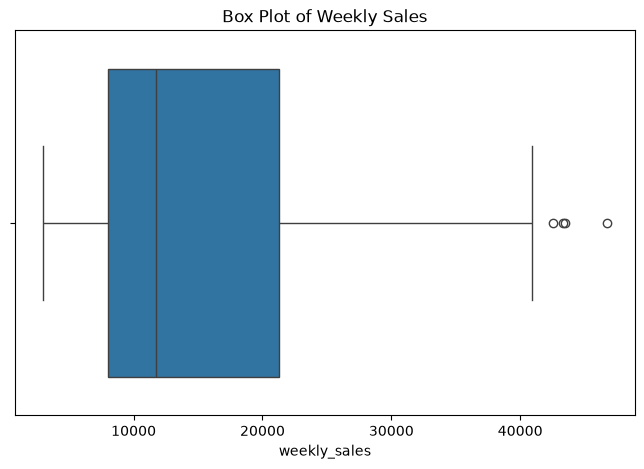

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

sns.boxplot(x=df3["weekly_sales"])

plt.title("Box Plot of Weekly Sales")

plt.show()

In [74]:
df3.describe()

,record_id,year,day_of_year,week_of_year,month,weekly_sales,units_sold,is_promotion,promotion_discount,store_size_factor,avg_temperature_c
count,5200.000000,5200.000000,5200.000000,5200.00000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000
mean,2600.500000,2021.500000,26.500000,26.75000,6.490385,14642.365473,496.910962,0.264615,0.040048,1.066000,15.028385
std,1501.255031,1.118142,15.009774,15.01602,3.433750,8056.091109,314.380287,0.441171,0.073221,0.154774,9.875727
min,1.000000,2020.000000,1.000000,1.00000,1.000000,2970.180000,75.000000,0.000000,0.000000,0.888000,-16.900000
25%,1300.750000,2020.750000,13.750000,14.00000,3.750000,8029.455000,256.750000,0.000000,0.000000,0.923000,7.100000
50%,2600.500000,2021.500000,26.500000,27.00000,6.500000,11718.220000,402.500000,0.000000,0.000000,1.059000,14.900000
75%,3900.250000,2022.250000,39.250000,40.00000,9.250000,21247.732500,664.250000,1.000000,0.060000,1.147000,22.800000
max,5200.000000,2023.000000,52.000000,53.00000,12.000000,46710.320000,2136.000000,1.000000,0.250000,1.313000,44.100000


In [80]:
from scipy.stats import zscore

df1["z_score"] = zscore(df1["age"])

In [82]:
print(df1[["age", "z_score"]])

      age  z_score
0    22.0      NaN
1    38.0      NaN
2    26.0      NaN
3    35.0      NaN
4    35.0      NaN
..    ...      ...
884  27.0      NaN
885  19.0      NaN
886   NaN      NaN
887  26.0      NaN
888  32.0      NaN

[889 rows x 2 columns]


In [84]:
outliers = df1[df1["z_score"].abs() > 3]

print(outliers)

Empty DataFrame
Columns: [survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, alone, z_score]
Index: []


In [87]:
df = df1[df1["z_score"].abs() <= 3]
print(outliers)

Empty DataFrame
Columns: [survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, alone, z_score]
Index: []


### there are no outlier for age 

#  Data type correction

In [90]:
df4 = pd.read_csv("dirty_retail_sales_wrong_datatypes.csv")



In [92]:
df4.head()

,record_id,date,year,day_of_year,week_of_year,month,store_id,category,weekly_sales,units_sold,is_promotion,promotion_discount,store_size_factor,avg_temperature_c
0,1,2020-01-06,2020,6,2,1,S001,Electronics,25000,120.0,Yes,10,0.888,6.0
1,2,06/01/2020,2020,13,3,1,S002,Furniture,Thirty Thousand,130.0,No,5,0.888,-1.8
2,3,2020/01/20,Two Thousand Twenty,20,4,1,S003,Grocery,18000,110.0,TRUE,15,0.888,19.1
3,4,20-Jan-2020,2020,Twenty Seven,5,1,S004,Clothing,22000abc,125.0,FALSE,20,0.888,2.9
4,5,2020-02-03,2020,34,6,February,S005,Toys,26000,NaN,Y,10,0.888,5.2


In [93]:
df.dtypes

survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
z_score        float64
dtype: object

In [97]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           10 non-null     int64  
 1   date                9 non-null      str    
 2   year                10 non-null     str    
 3   day_of_year         10 non-null     str    
 4   week_of_year        10 non-null     int64  
 5   month               10 non-null     str    
 6   store_id            10 non-null     str    
 7   category            10 non-null     str    
 8   weekly_sales        9 non-null      str    
 9   units_sold          9 non-null      float64
 10  is_promotion        10 non-null     str    
 11  promotion_discount  10 non-null     str    
 12  store_size_factor   10 non-null     str    
 13  avg_temperature_c   10 non-null     str    
dtypes: float64(1), int64(2), str(11)
memory usage: 1.2 KB


In [100]:
df4["weekly_sales"].dtype

<StringDtype(storage='python', na_value=nan)>

In [102]:
df.dtypes.value_counts()

str        7
int64      4
float64    3
bool       2
Name: count, dtype: int64

In [108]:
df4.select_dtypes(include="number")

,record_id,year,week_of_year,units_sold
0,1,2020.0,2,120.0
1,2,2020.0,3,130.0
2,3,NaN,4,110.0
3,4,2020.0,5,125.0
4,5,2020.0,6,NaN
5,6,2020.0,7,140.0
6,7,2020.0,8,135.0
7,8,2020.0,9,150.0
8,9,2020.0,10,160.0
9,10,2020.0,11,170.0


In [107]:
df4.select_dtypes(include="str").columns

Index(['date', 'day_of_year', 'month', 'store_id', 'category', 'weekly_sales',
       'is_promotion', 'promotion_discount', 'store_size_factor',
       'avg_temperature_c'],
      dtype='str')

In [106]:
df4["year"] = pd.to_numeric(df4["year"], errors="coerce")

In [110]:
df4["avg_temperature_c"] = pd.to_numeric(df4["avg_temperature_c"],errors="coerce")

In [112]:
df4["date"] = pd.to_datetime(df4["date"],errors="coerce")

In [113]:
df4.head(10)

,record_id,date,year,day_of_year,week_of_year,month,store_id,category,weekly_sales,units_sold,is_promotion,promotion_discount,store_size_factor,avg_temperature_c
0,1,2020-01-06,2020.0,6,2,1,S001,Electronics,25000,120.0,Yes,10,0.888,6.0
1,2,NaT,2020.0,13,3,1,S002,Furniture,Thirty Thousand,130.0,No,5,0.888,-1.8
2,3,NaT,NaN,20,4,1,S003,Grocery,18000,110.0,TRUE,15,0.888,19.1
3,4,NaT,2020.0,Twenty Seven,5,1,S004,Clothing,22000abc,125.0,FALSE,20,0.888,2.9
4,5,2020-02-03,2020.0,34,6,February,S005,Toys,26000,NaN,Y,10,0.888,5.2
5,6,NaT,2020.0,41,7,2,S006,Sports,NaN,140.0,N,0,0.888,10.5
6,7,NaT,2020.0,48,8,2,S007,Books,"27,500",135.0,1,5,0.888,15.0
7,8,NaT,2020.0,55,9,2,S008,Electronics,₹30000,150.0,0,Ten,0.888,20.1
8,9,NaT,2020.0,62,10,3,S009,Furniture,35000,160.0,Yes,15%,Large,18.2
9,10,NaT,2020.0,69,11,3,S010,Grocery,$40000,170.0,No,20,Medium,NaN


In [116]:
df4["is_promotion"] = (df4["is_promotion"].astype(str).str.strip().str.lower())

df4["is_promotion"] = df4["is_promotion"].replace({
    "yes": True,
    "y": True,
    "true": True,
    "1": True,
    "no": False,
    "n": False,
    "false": False,
    "0": False
})

In [117]:
df4["weekly_sales"] = (
    df4["weekly_sales"]
    .astype(str)
    .str.replace(r"[₹$,]", "", regex=True)
    .str.replace(",", "", regex=False)
    .str.replace("abc", "", regex=False)
)

df4["weekly_sales"] = pd.to_numeric(
    df4["weekly_sales"],
    errors="coerce"
)

In [118]:
month_map = {
    "January":1,
    "February":2,
    "March":3,
    "April":4
}

df4["month"] = df4["month"].replace(month_map)

df4["month"] = pd.to_numeric(df4["month"],errors="coerce")

In [119]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   record_id           10 non-null     int64         
 1   date                2 non-null      datetime64[us]
 2   year                9 non-null      float64       
 3   day_of_year         10 non-null     str           
 4   week_of_year        10 non-null     int64         
 5   month               10 non-null     int64         
 6   store_id            10 non-null     str           
 7   category            10 non-null     str           
 8   weekly_sales        8 non-null      float64       
 9   units_sold          9 non-null      float64       
 10  is_promotion        10 non-null     object        
 11  promotion_discount  10 non-null     str           
 12  store_size_factor   10 non-null     str           
 13  avg_temperature_c   9 non-null      float64       
dtypes: datet

In [120]:
df4.to_csv("cleaned_retail_sales.csv", index=False)

print("File saved successfully!")

File saved successfully!
